In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from pathlib import Path

OUTPUT_DIR = Path('perturbation_vs_score_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('targeted_attack_results/per_sample_attack_results.csv')
df = df[df['success'] == 1].copy()
print(f'Successfully attacked samples: {len(df)} (across both regimes)')
print(f'Columns: {list(df.columns)}')

Successfully attacked samples: 4117 (across both regimes)
Columns: ['test_idx', 'true_label', 'regime', 'score1_rank', 'score1_value', 'score2_value', 'orig_pred', 'orig_confidence', 'adv_pred', 'adv_confidence_orig_class', 'success', 'l2_norm', 'weighted_l2_norm', 'confidence_drop']


## 1. Scatter Plots: L2 Perturbation vs Noise Score

Saved scatter_l2_vs_score.png


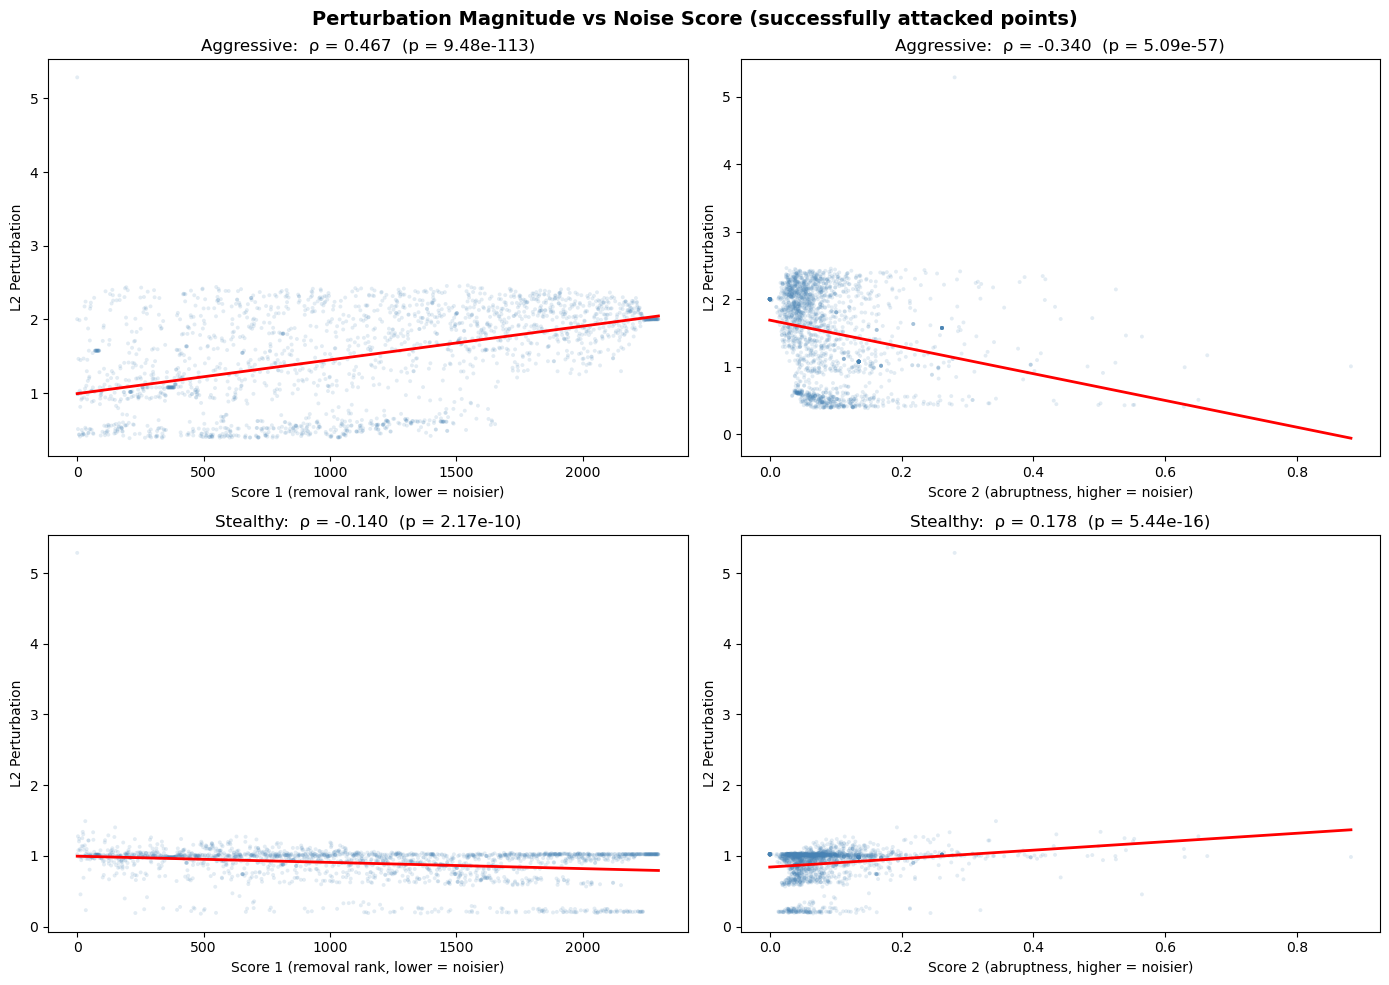

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    (0, 0, 'aggressive', 'score1_rank',  'Score 1 (removal rank, lower = noisier)'),
    (0, 1, 'aggressive', 'score2_value', 'Score 2 (abruptness, higher = noisier)'),
    (1, 0, 'stealthy',   'score1_rank',  'Score 1 (removal rank, lower = noisier)'),
    (1, 1, 'stealthy',   'score2_value', 'Score 2 (abruptness, higher = noisier)'),
]

for row, col, regime, score_col, xlabel in configs:
    ax = axes[row, col]
    sub = df[df['regime'] == regime]

    x = sub[score_col].values
    y = sub['l2_norm'].values
    rho, pval = spearmanr(x, y)

    ax.scatter(x, y, alpha=0.15, s=8, color='steelblue', edgecolors='none')

    # Trend line (polynomial fit for visual guide)
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2 Perturbation')
    ax.set_title(f'{regime.capitalize()}:  \u03C1 = {rho:.3f}  (p = {pval:.2e})')

fig.suptitle('Perturbation Magnitude vs Noise Score (successfully attacked points)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'scatter_l2_vs_score.png', dpi=150, bbox_inches='tight')
print('Saved scatter_l2_vs_score.png')
plt.show()

## 2. Binned Mean L2 Perturbation by Noise Score Decile

Saved binned_l2_by_decile.png


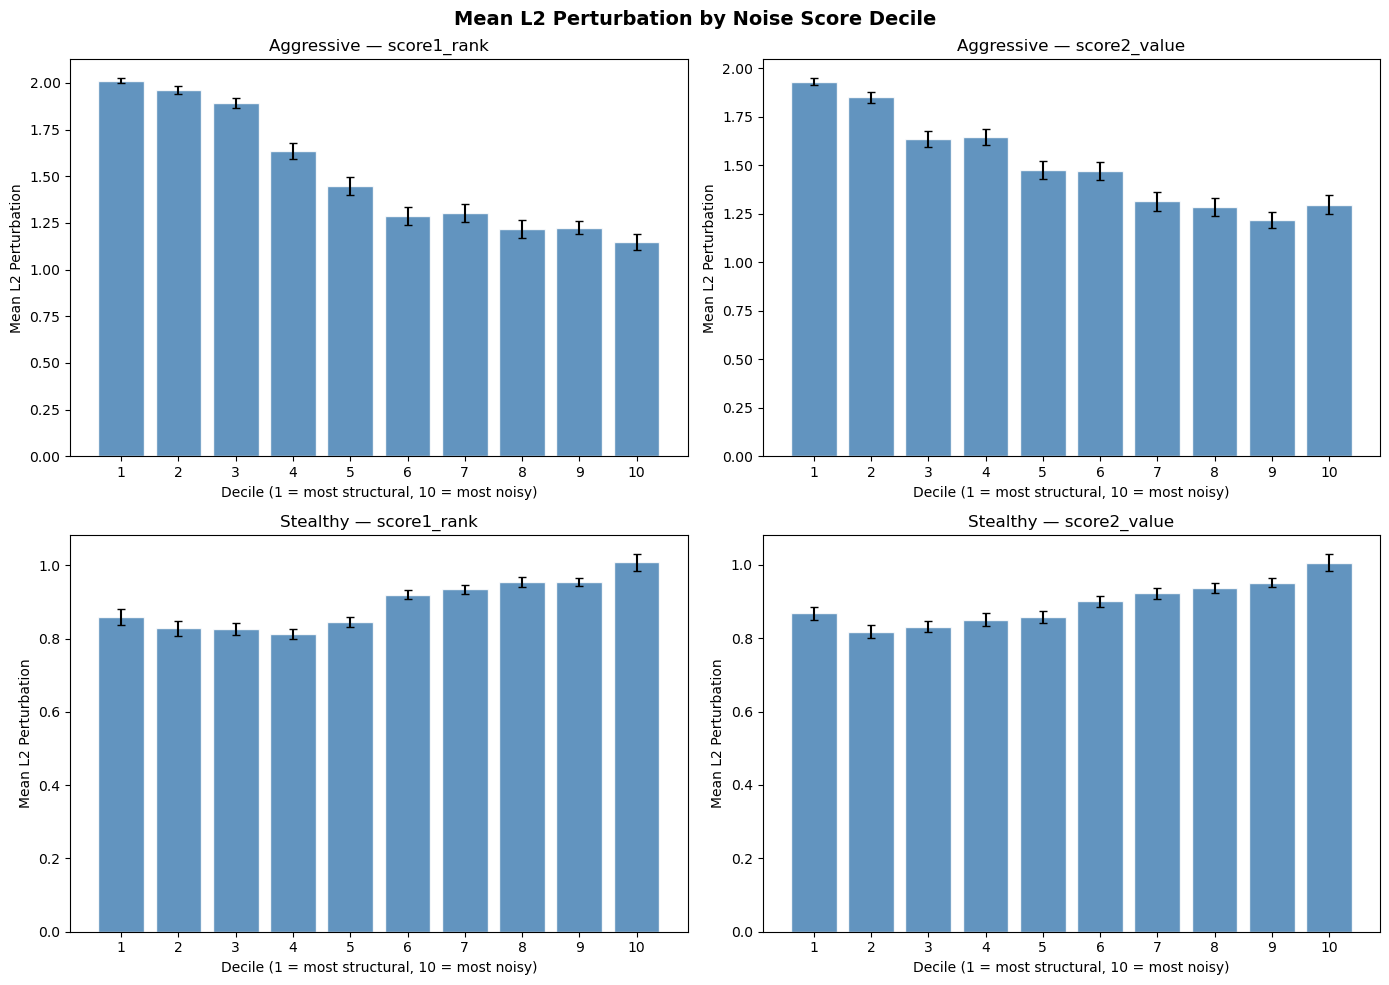

In [3]:
N_BINS = 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, col, regime, score_col, xlabel in configs:
    ax = axes[row, col]
    sub = df[df['regime'] == regime].copy()

    # For Score 1, rank 0 = noisiest → bin 1 = noisiest.
    # For Score 2, highest value = noisiest → bin 1 = noisiest.
    # We label bins as "most structural" (left) to "most noisy" (right).
    if score_col == 'score1_rank':
        sub['bin'] = pd.qcut(sub[score_col], N_BINS, labels=False)
        sub['bin'] = N_BINS - 1 - sub['bin']  # flip so 0 = structural, 9 = noisy
    else:
        sub['bin'] = pd.qcut(sub[score_col], N_BINS, labels=False, duplicates='drop')

    grouped = sub.groupby('bin')['l2_norm'].agg(['mean', 'std', 'count'])
    se = grouped['std'] / np.sqrt(grouped['count'])

    ax.bar(grouped.index, grouped['mean'], yerr=se, capsize=3,
           color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xlabel(f'Decile (1 = most structural, {N_BINS} = most noisy)')
    ax.set_ylabel('Mean L2 Perturbation')
    ax.set_title(f'{regime.capitalize()} — {score_col}')
    ax.set_xticks(range(N_BINS))
    ax.set_xticklabels(range(1, N_BINS + 1))

fig.suptitle('Mean L2 Perturbation by Noise Score Decile', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'binned_l2_by_decile.png', dpi=150, bbox_inches='tight')
print('Saved binned_l2_by_decile.png')
plt.show()